## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Results LLM MLM-to-morphology model**](#tulemused_llm_mlm)
3. [**Analyzing the results**](#tulemuste_analyys)

[end](#end)


### Conclusive evaluation results for the model

> Note that the evaluation results are based on only the form label pairs, and thus do not take into account the POS tags.

| Model                                            | Accuracy | Precision | Recall | F1-score |
| ------------------------------------------------ | -------: | --------: | -----: | -------: |
| LLM MLM-to-morphology model                      |   83.27% |    87.92% | 83.27% |   85.33% |
| LLM MLM-to-morphology model (lenient)            |   86.00% |    87.82% | 86.00% |   86.89% |
| LLM MLM-to-morphology model (lenient, no others) |   87.84% |    87.83% | 87.84% |   87.82% |

Predictions outside the set of possible labels: **165/7886 (2.09%)**


### Imports


In [1]:
print("Test")

Test


In [2]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [ ]:
overall_df = pd.read_parquet(
    HOMONYMS_DIRS["processed"] / "homonyms_overall_updated_sentences.parquet"
)

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [ ]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


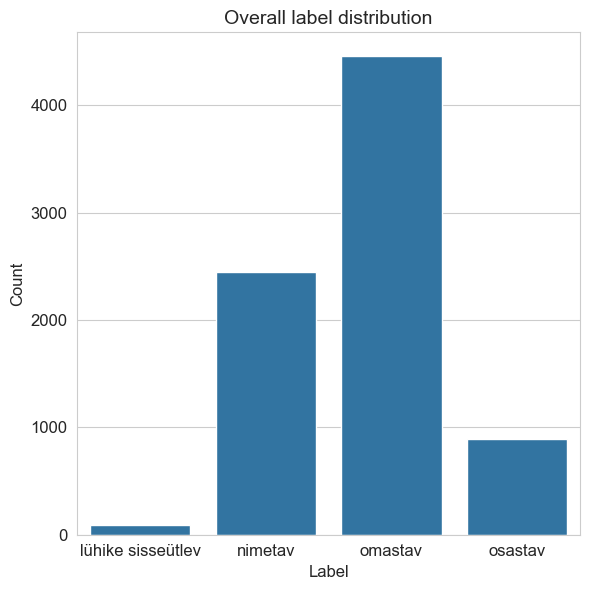

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


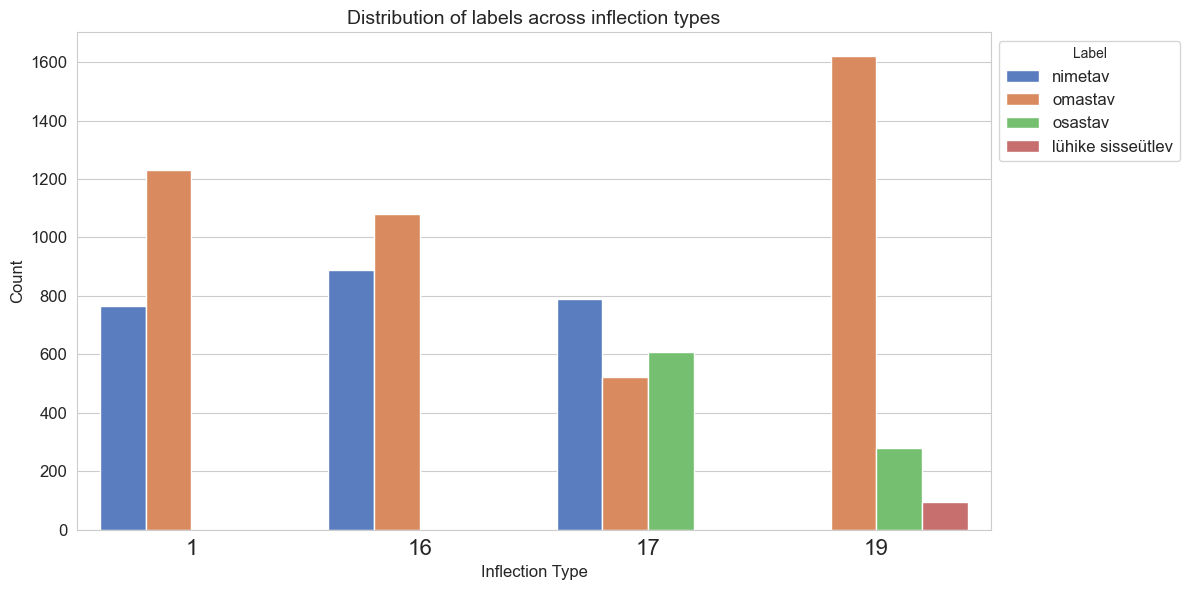

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='tulemused_llm_mlm'></a>


### LLM MLM predictions for the homonym dataset


In [3]:
df_output_path = (
    HOMONYMS_DIRS["processed"] / "homonyms_llm_mlm_predictions_full.parquet"
)
model_name = "LLM_MLM"
results_df = pd.read_parquet(df_output_path)
display(results_df.head())

,id,candidates,pred_label,true_label,predicted_form_distribution,source_sentence,target_word,word_span
0,0,"[saaja, pälvija, laureaadi, kandidaadi, osavõtja, pretendendi, võistleja, tiitliomaniku, võidumehe, austatu]",sg g,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': 0.8999999999999999, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.1, 'sg p': None, 'sg ter': None, 'sg tr': None, 'sid': None, 'tama': None, 'tavat': None, 'te': None, 'ti': None, 'tud': None, 'vad': None, 'vat': None}","Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]"
1,1,"[hüpoteesi, mudeli, käsitluse, lähenemise, kontseptsiooni, idee, doktriini, teooriate, kontseptsioonide, vaatenurga]",sg g,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': 0.2, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': 0.7, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.1, 'sg p': None, 'sg ter': None, 'sg tr': None, 'sid': None, 'tama': None, 'tavat': None, 'te': None, 'ti': None, 'tud': None, 'vad': None, 'vat': None}","Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]"
2,2,"[teavitus, reklaam, üritus, programm, kampaania, algatus, projekt, sündmus, koostöö, pakkumine]",sg n,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': None, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.9999999999999999, 'sg p': None, 'sg ter': None, 'sg tr': None, 'sid': None, 'tama': None, 'tavat': None, 'te': None, 'ti': None, 'tud': None, 'vad': None, 'vat': None}","""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]"
3,3,"[täpne, sobiv, vastav, kohane, õiglane, mõistlik, arukas, kavakohane, õigesti põhjendatud, õigustatud]",sg n,sg n,"{'': 0.125, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': 0.025, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': None, 'sg ill': None, 'sg in': No

In [4]:
# Load original results dataframe
results_df_v2 = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2.csv",
    index_col=False,
)

# Filter out only the rows in the original results that correspond to the sentences in the LLM sample
llm_sentences = results_df["source_sentence"].unique()
results_df_v2_llm_subset = results_df_v2[results_df_v2["sentence"].isin(llm_sentences)]
print(
    len(results_df_v2_llm_subset),
    "rows in BertMorphTaggerV2 results corresponding to LLM homonyms subset",
)
print(len(results_df), "rows in LLM MLM results for homonyms subset")

# Add inflection type column from subset of original results to LLM results
# Create a new column in the LLM results dataframes to hold the inflection type
results_df["inflection_type"] = results_df_v2_llm_subset["inflection_type"].values

7886 rows in BertMorphTaggerV2 results corresponding to LLM homonyms subset
7886 rows in LLM MLM results for homonyms subset


In [5]:
results_df_split, results_df_filtered = (
    create_lenient_labels_and_split_counts_and_cases(
        results_df, "true_label", "pred_label"
    )
)

results_df_filtered_possibles = results_df_filtered[
    (results_df_filtered["true_case_lenient"] != "other")
    & (results_df_filtered["pred_case_lenient"] != "other")
]

print(f"{model_name} results:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient):")
display_metrics_and_classification_report(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)
print(f"\n{model_name} results (lenient, excluding 'other'):")
display_metrics_and_classification_report(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    show_metrics=True,
    show_classification_report=False,
)

# Count cases where "other" was predicted and the proportion of those out of all predictions
other_pred_count = (results_df_filtered["pred_case_lenient"] == "other").sum()
total_pred_count = len(results_df_filtered)
print(
    f'\nNumber of "other" cases: {other_pred_count} out of {total_pred_count} ({other_pred_count / total_pred_count:.2%})'
)

LLM_MLM results:
Overall results
Accuracy:  83.27%
Precision: 87.92%
Recall:    83.27%
F1-score:  85.33%

LLM_MLM results (lenient):
Overall results
Accuracy:  86.00%
Precision: 87.82%
Recall:    86.00%
F1-score:  86.89%

LLM_MLM results (lenient, excluding 'other'):
Overall results
Accuracy:  87.84%
Precision: 87.83%
Recall:    87.84%
F1-score:  87.82%

Number of "other" cases: 165 out of 7886 (2.09%)


In [6]:
# Print classification reports
print(f"{model_name} classification report:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=False,
    show_classification_report=True,
)

LLM_MLM classification report:
Overall results - Classification Report
              precision    recall  f1-score   support

                   0.00      0.00      0.00         0
           ?       0.00      0.00      0.00         0
         adt       0.67      0.19      0.30        94
          da       0.00      0.00      0.00         0
          ma       0.00      0.00      0.00         0
         nud       0.00      0.00      0.00         0
       pl ab       0.00      0.00      0.00         0
      pl all       0.00      0.00      0.00         0
       pl el       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
      pl kom       0.00      0.00      0.00         0
        pl n       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg ab       0.00      0.00      0.00         0
       sg ad       0.00      0.00      0.00         0
      sg all       0.00      0.00      0.00         0
       sg 

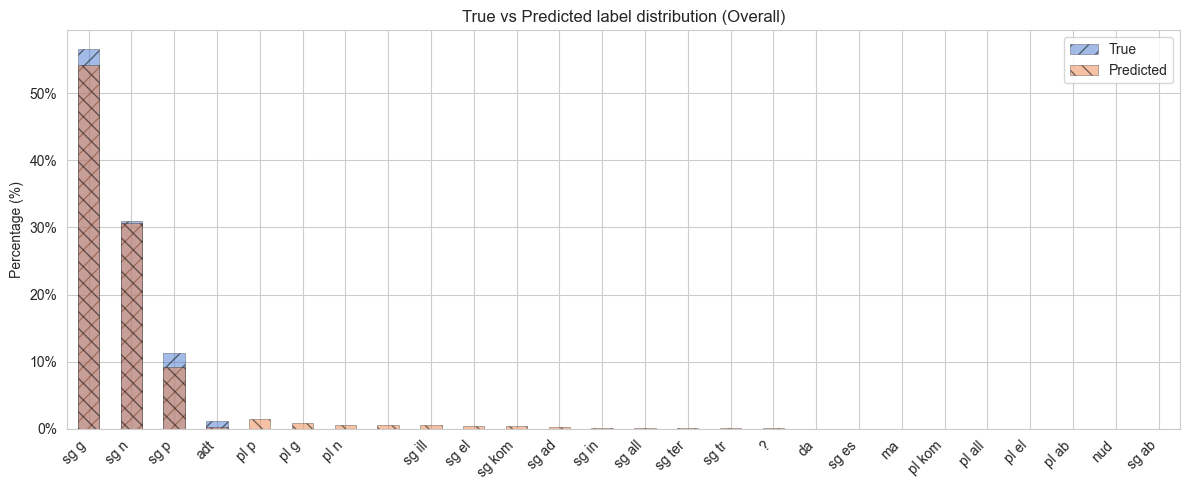

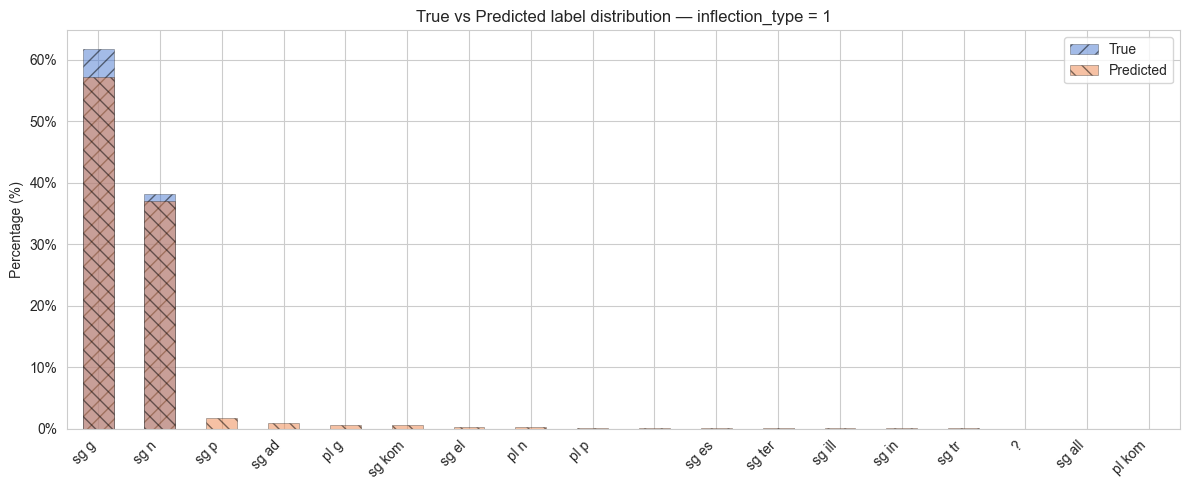

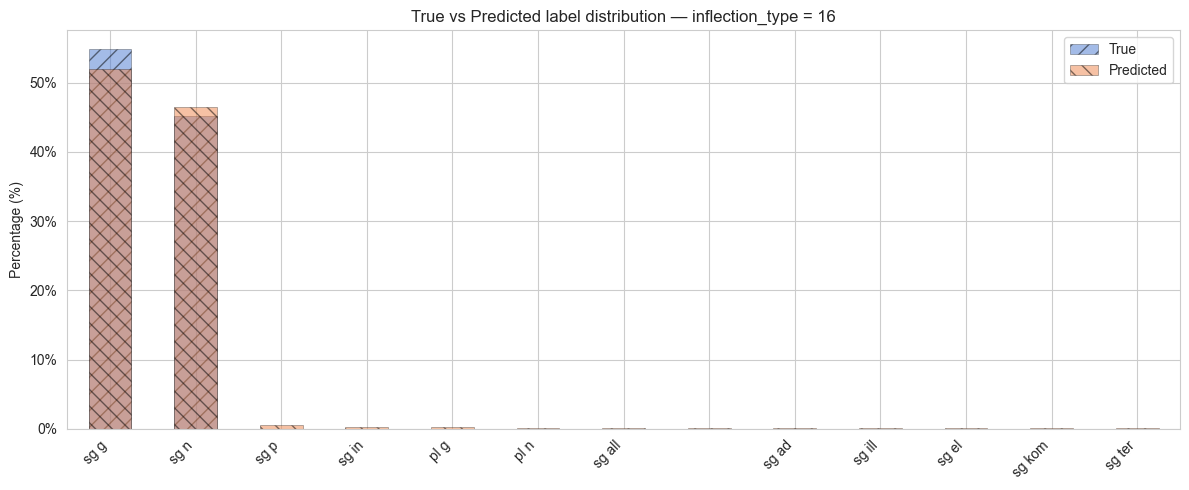

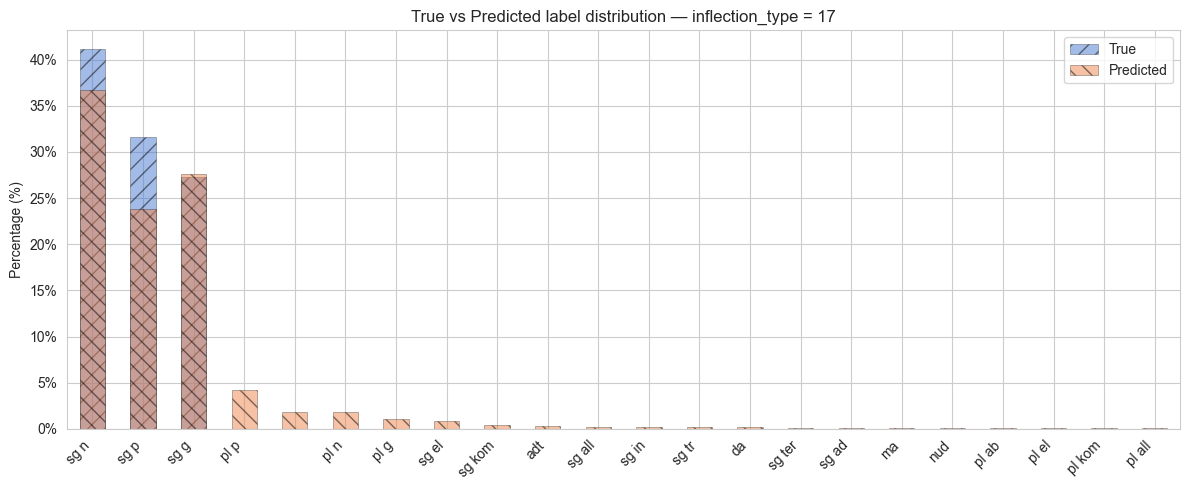

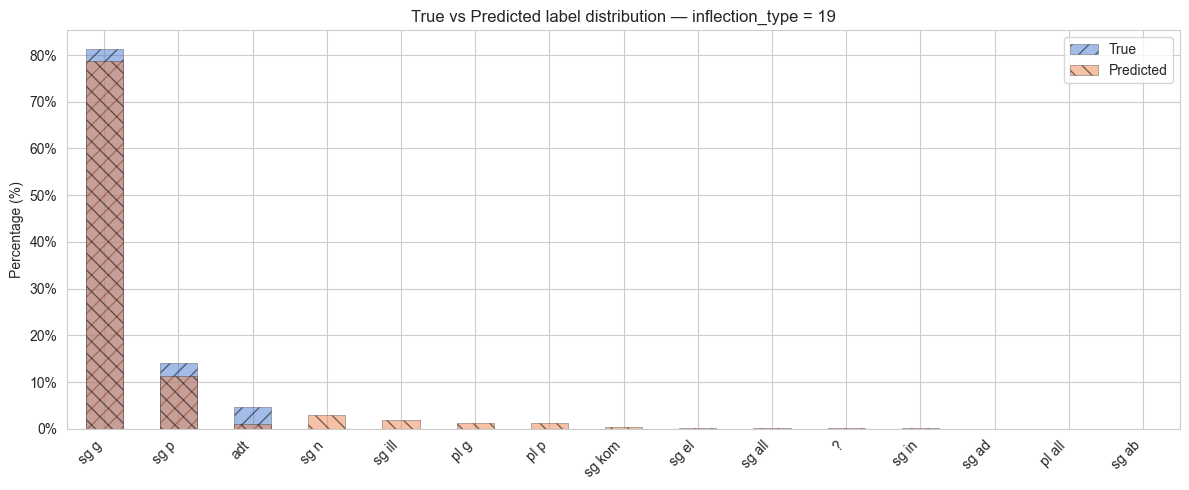

In [7]:
plot_true_vs_pred_by_inflection(
    results_df,
    figsize=(12, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar",
)

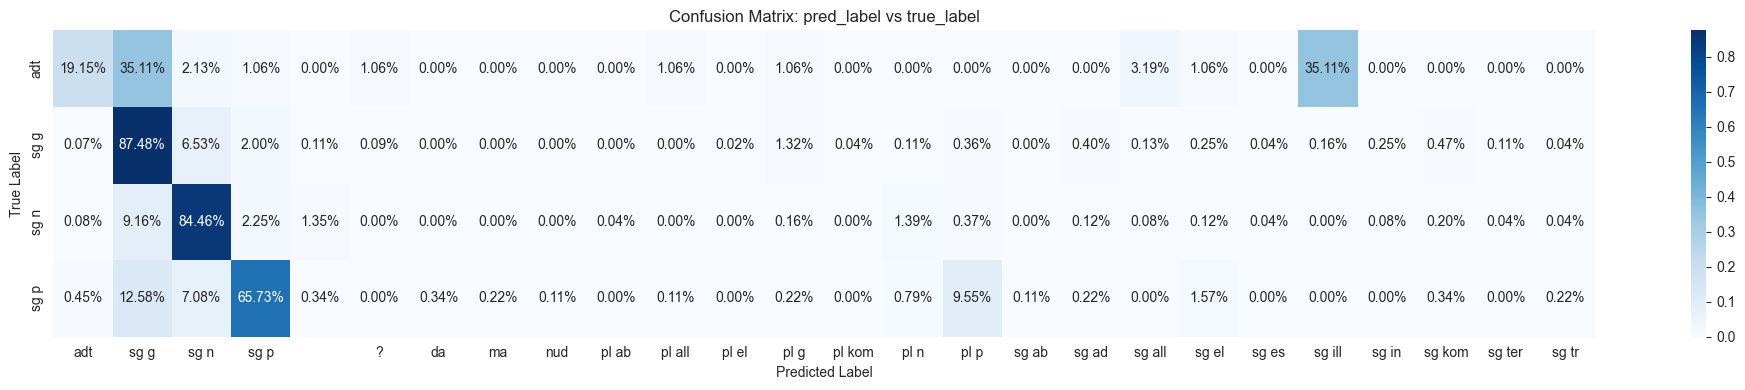

Confusion Matrix: pred_label vs true_label - Predicted-only labels (not present in true labels):
   predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  pl p    110       1.39              True              0
1                  pl g     66       0.84              True              0
2                  pl n     46       0.58              True              0
3                           41       0.52              True              0
4                sg ill     40       0.51              True              0
5                 sg el     29       0.37              True              0
6                sg kom     29       0.37              True              0
7                 sg ad     23       0.29              True              0
8                 sg in     13       0.16              True              0
9                sg all     11       0.14              True              0
10               sg ter      6       0.08              True              0
11 

In [8]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    fig_size=(20, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM.png"),
    significant_pred_threshold_pct=0,
)

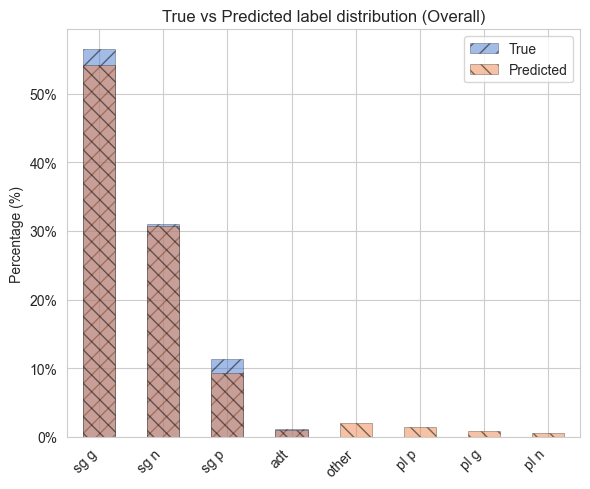

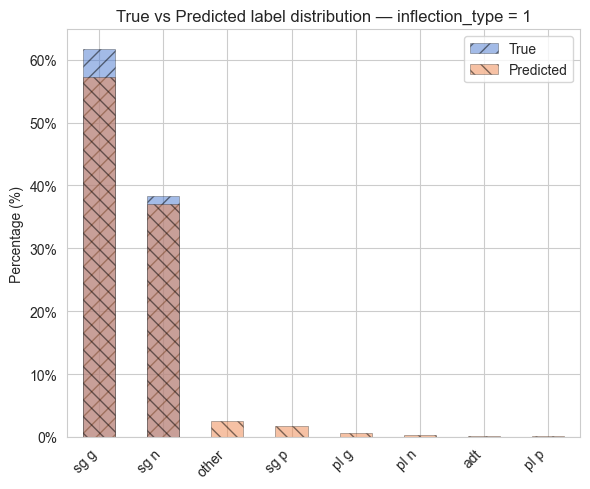

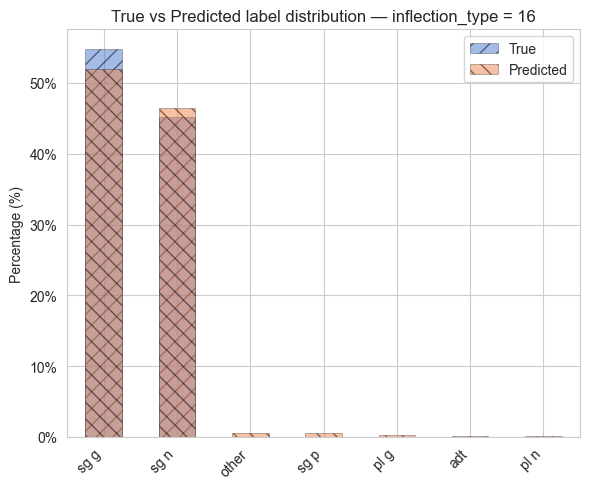

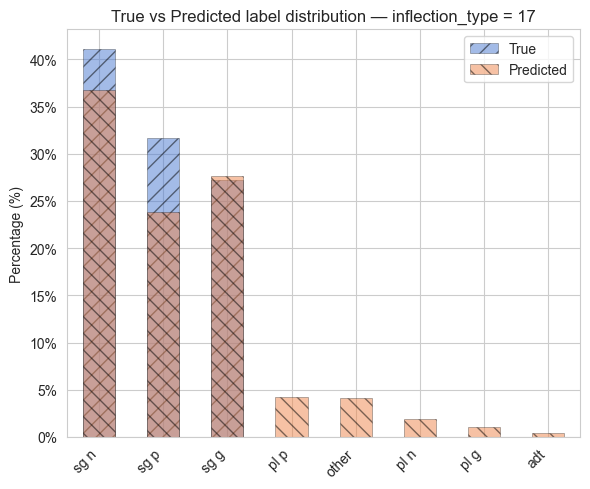

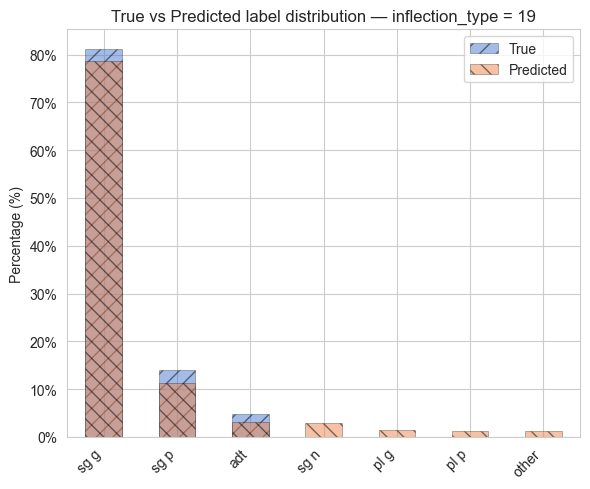

In [9]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_label_lenient",
    pred_col="pred_label_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_lenient_bar",
)

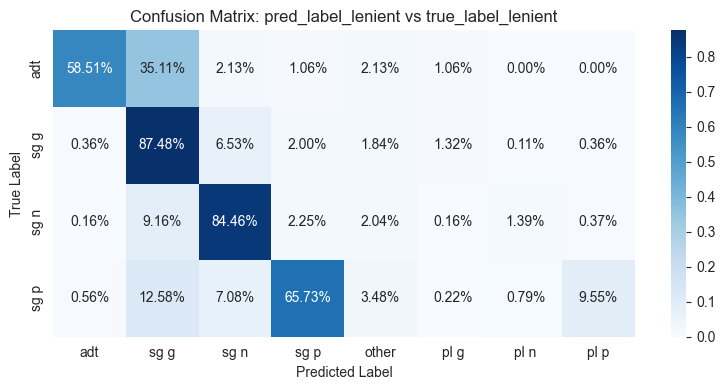

Confusion Matrix: pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other    165       2.09              True              0
1                 pl p    110       1.39              True              0
2                 pl g     66       0.84              True              0
3                 pl n     46       0.58              True              0
Sum of true labels count: 7886


In [10]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    fig_size=(8, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient.png"),
    significant_pred_threshold_pct=0,
)

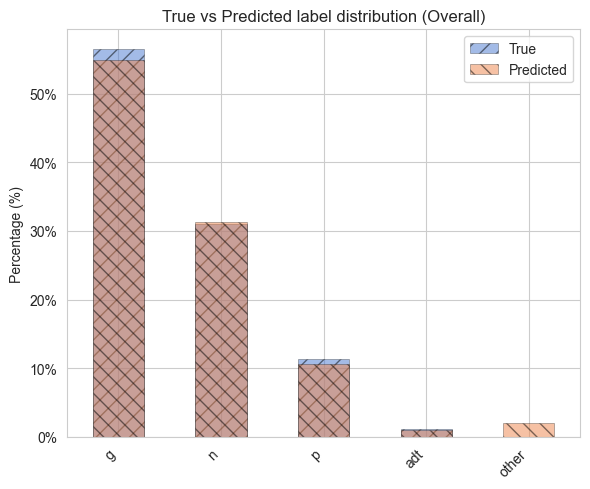

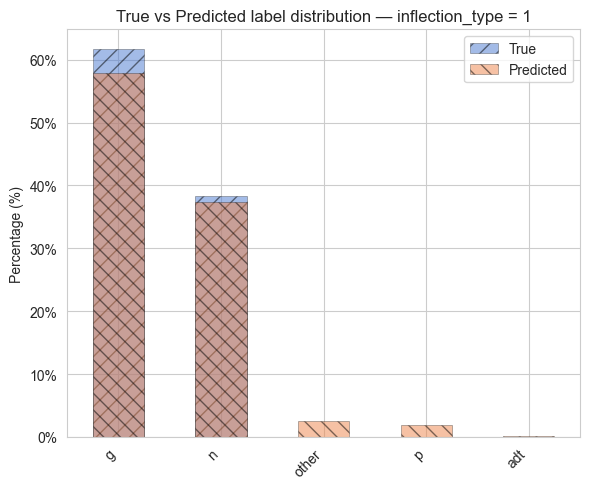

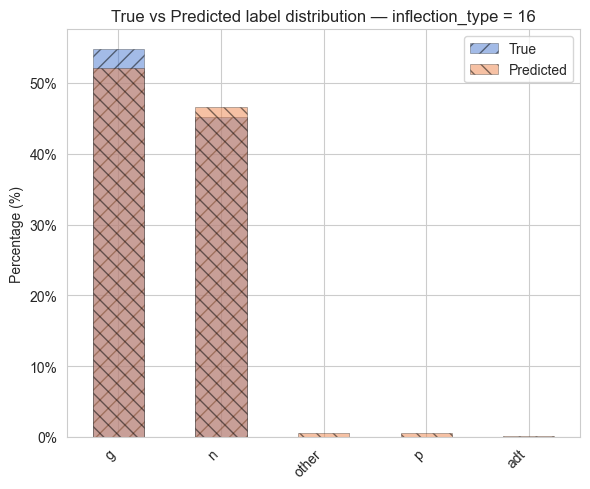

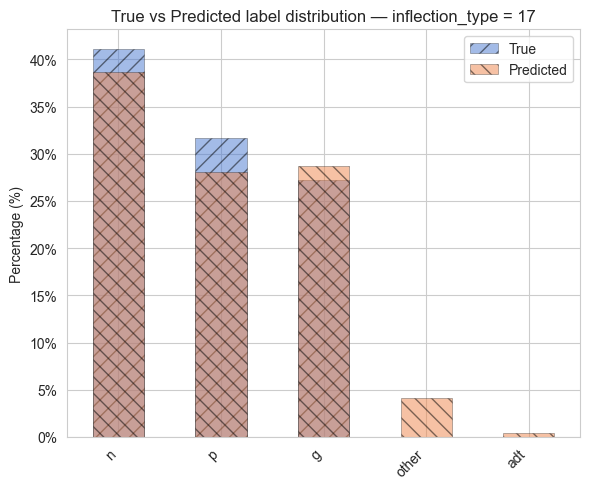

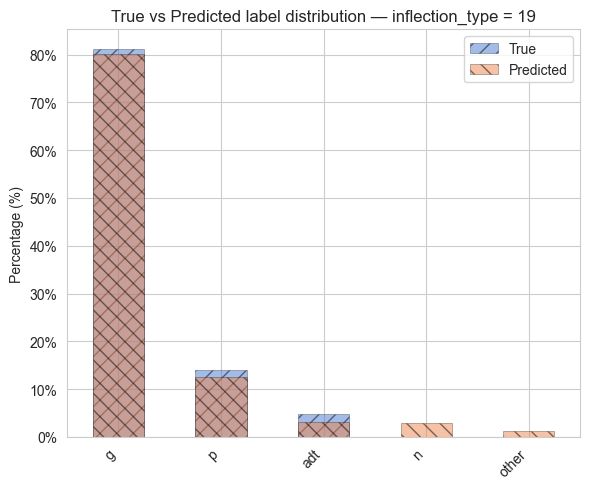

In [11]:
plot_true_vs_pred_by_inflection(
    results_df_filtered,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case",
)

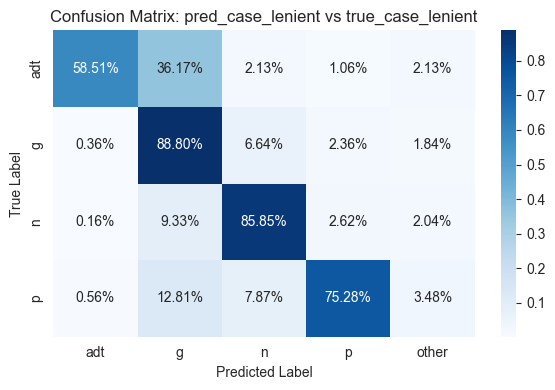

Confusion Matrix: pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other    165       2.09              True              0
Sum of true labels count: 7886


In [12]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case.png"
    ),
    significant_pred_threshold_pct=0,
)

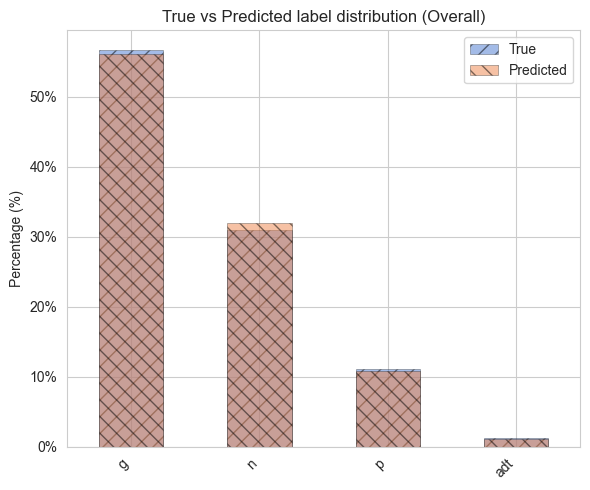

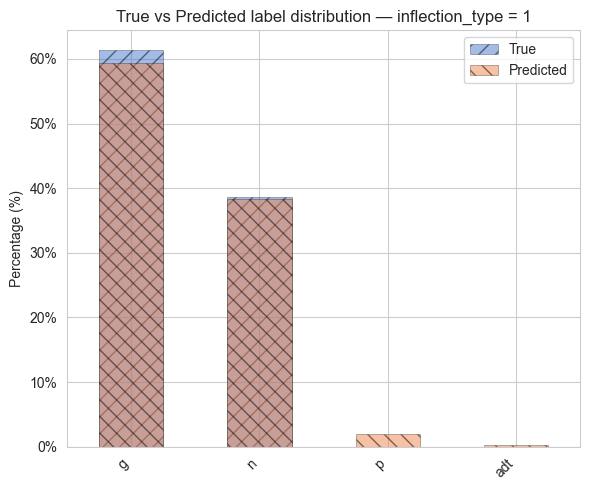

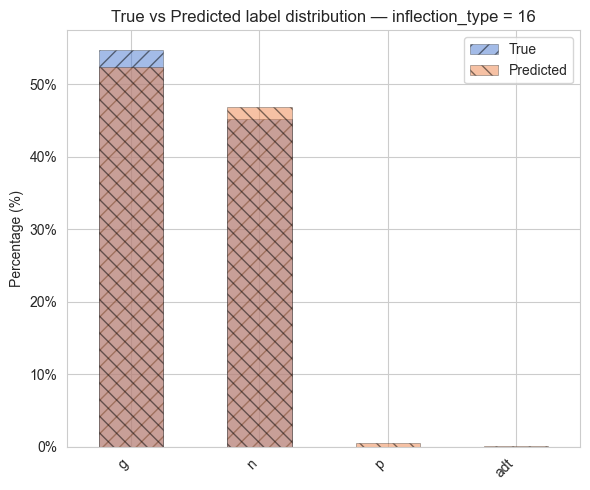

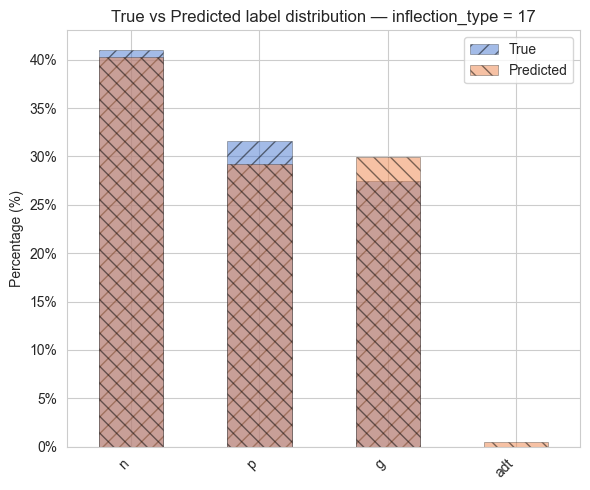

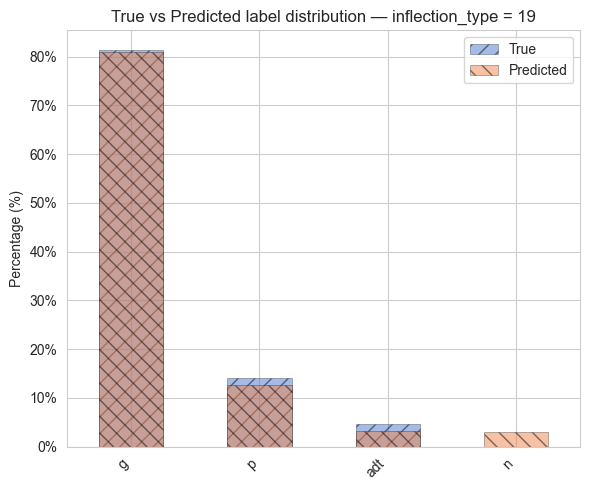

In [13]:
plot_true_vs_pred_by_inflection(
    results_df_filtered_possibles,
    label_col="true_case_lenient",
    pred_col="pred_case_lenient",
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    save_dir=str(HOMONYMS_PLOTS_DIR / model_name),
    save_prefix=f"{model_name}_bar_lenient_case_possibles",
)

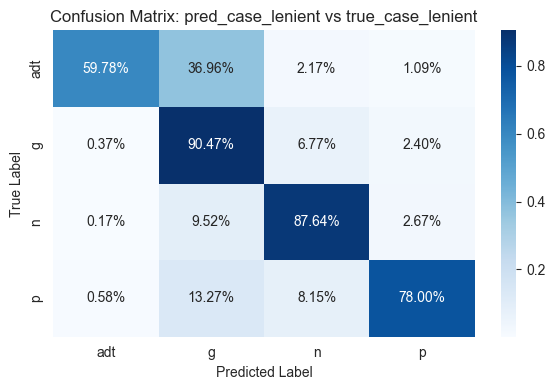

In [14]:
# Plot confusion matrices for both models
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_possibles.png"
    ),
    significant_pred_threshold_pct=0,
)

In [15]:
# Generate results per inflection type
print(f"{model_name} results per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

LLM_MLM results per inflection type:
inflection_type=1
Accuracy:  86.42%
Precision: 91.75%
Recall:    86.42%
F1-score:  89.00%
inflection_type=16
Accuracy:  88.27%
Precision: 89.84%
Recall:    88.27%
F1-score:  89.01%
inflection_type=17
Accuracy:  72.87%
Precision: 82.98%
Recall:    72.87%
F1-score:  77.35%
inflection_type=19
Accuracy:  85.22%
Precision: 92.97%
Recall:    85.22%
F1-score:  88.02%


In [16]:
# Generate classification reports per inflection type
print(f"{model_name} classification reports per inflection type:")
display_metrics_and_classification_report(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=False,
    show_classification_report=True,
)

LLM_MLM classification reports per inflection type:
inflection_type=1 - Classification Report
              precision    recall  f1-score   support

                   0.00      0.00      0.00         0
           ?       0.00      0.00      0.00         0
        pl g       0.00      0.00      0.00         0
      pl kom       0.00      0.00      0.00         0
        pl n       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg ad       0.00      0.00      0.00         0
      sg all       0.00      0.00      0.00         0
       sg el       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.94      0.87      0.90      1232
      sg ill       0.00      0.00      0.00         0
       sg in       0.00      0.00      0.00         0
      sg kom       0.00      0.00      0.00         0
        sg n       0.89      0.86      0.87       764
        sg p       0.00      0.00      0.

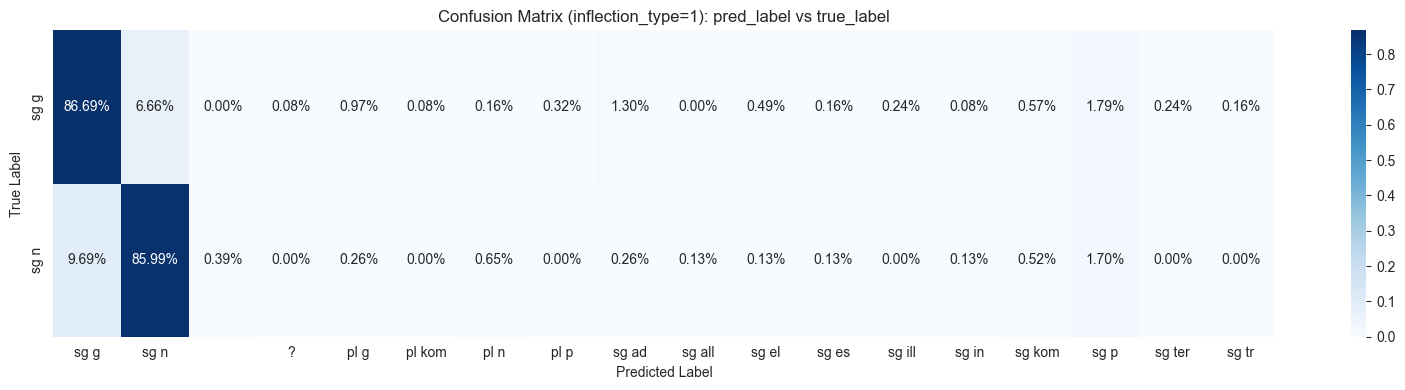

Confusion Matrix (inflection_type=1): pred_label vs true_label - Predicted-only labels (not present in true labels):
   predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  sg p     35       1.75              True              0
1                 sg ad     18       0.90              True              0
2                  pl g     14       0.70              True              0
3                sg kom     11       0.55              True              0
4                  pl n      7       0.35              True              0
5                 sg el      7       0.35              True              0
6                  pl p      4       0.20              True              0
7                            3       0.15              True              0
8                sg ter      3       0.15              True              0
9                sg ill      3       0.15              True              0
10                sg es      3       0.15              Tru

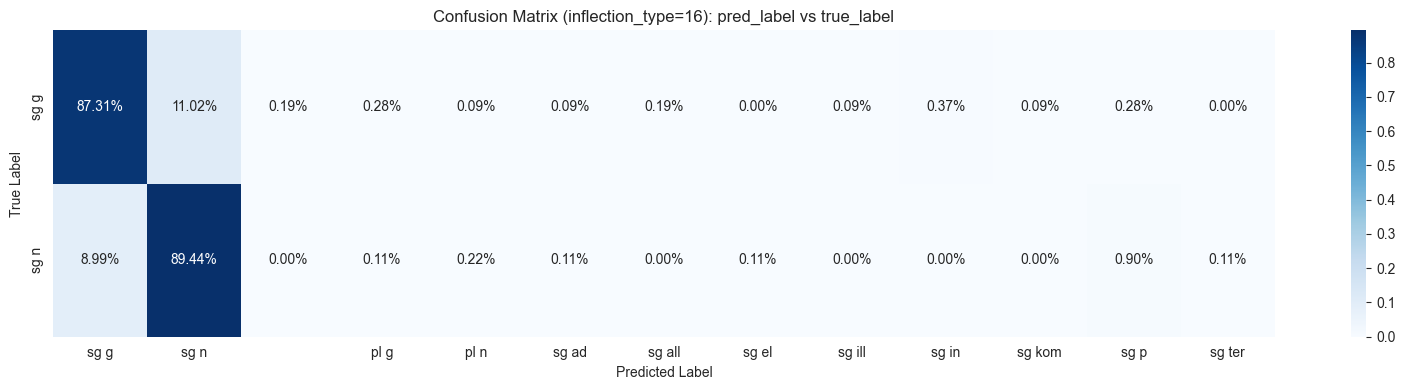

Confusion Matrix (inflection_type=16): pred_label vs true_label - Predicted-only labels (not present in true labels):
   predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  sg p     11       0.56              True              0
1                 sg in      4       0.20              True              0
2                  pl g      4       0.20              True              0
3                  pl n      3       0.15              True              0
4                            2       0.10              True              0
5                 sg ad      2       0.10              True              0
6                sg all      2       0.10              True              0
7                sg ill      1       0.05              True              0
8                 sg el      1       0.05              True              0
9                sg kom      1       0.05              True              0
10               sg ter      1       0.05              Tr

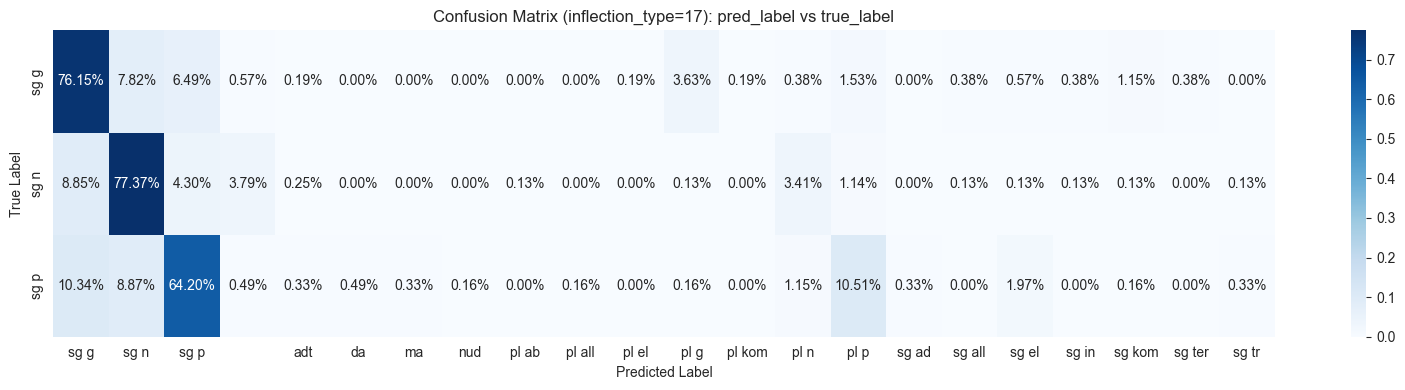

Confusion Matrix (inflection_type=17): pred_label vs true_label - Predicted-only labels (not present in true labels):
   predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  pl p     81       4.21              True              0
1                  pl n     36       1.87              True              0
2                           36       1.87              True              0
3                  pl g     21       1.09              True              0
4                 sg el     16       0.83              True              0
5                sg kom      8       0.42              True              0
6                   adt      5       0.26              True              0
7                    da      3       0.16              True              0
8                sg all      3       0.16              True              0
9                 sg in      3       0.16              True              0
10                sg tr      3       0.16              Tr

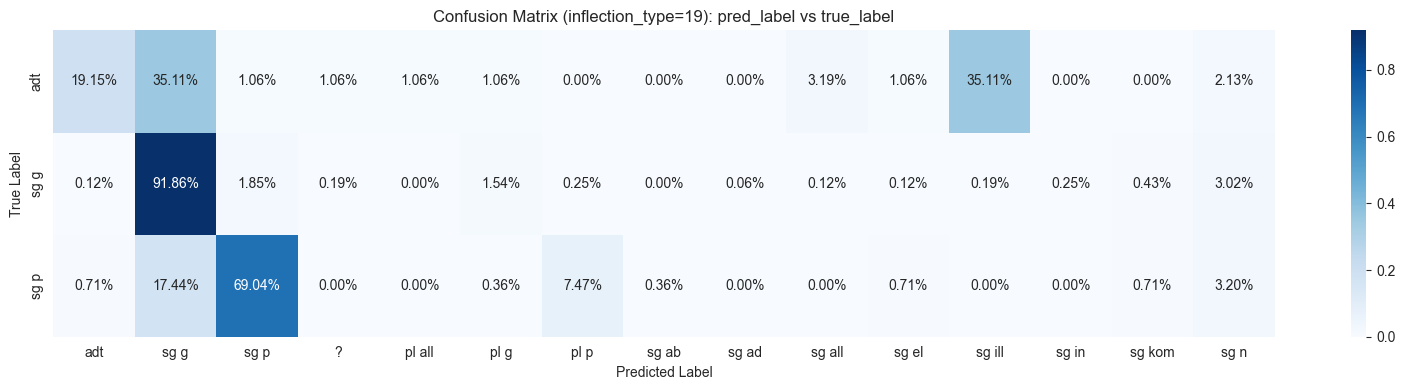

Confusion Matrix (inflection_type=19): pred_label vs true_label - Predicted-only labels (not present in true labels):
   predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  sg n     60       3.01              True              0
1                sg ill     36       1.80              True              0
2                  pl g     27       1.35              True              0
3                  pl p     25       1.25              True              0
4                sg kom      9       0.45              True              0
5                 sg el      5       0.25              True              0
6                sg all      5       0.25              True              0
7                     ?      4       0.20              True              0
8                 sg in      4       0.20              True              0
9                pl all      1       0.05              True              0
10                sg ab      1       0.05              Tr

In [17]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    fig_size=(16, 4),
    save_path=str(HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_infl.png"),
    significant_pred_threshold_pct=0,
)

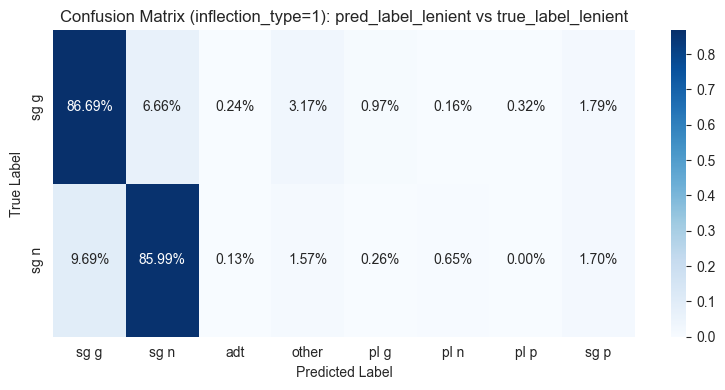

Confusion Matrix (inflection_type=1): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     51       2.56              True              0
1                 sg p     35       1.75              True              0
2                 pl g     14       0.70              True              0
3                 pl n      7       0.35              True              0
4                  adt      4       0.20              True              0
5                 pl p      4       0.20              True              0
Sum of true labels count: 1996


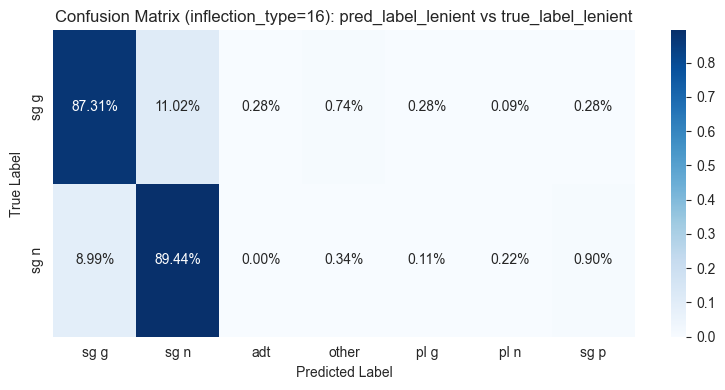

Confusion Matrix (inflection_type=16): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     11       0.56              True              0
1                 sg p     11       0.56              True              0
2                 pl g      4       0.20              True              0
3                  adt      3       0.15              True              0
4                 pl n      3       0.15              True              0
Sum of true labels count: 1970


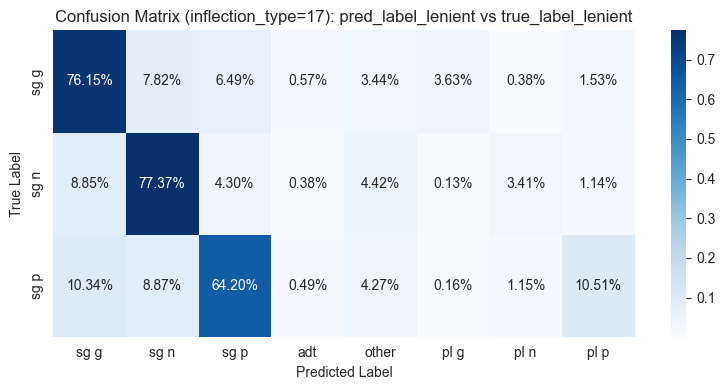

Confusion Matrix (inflection_type=17): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 pl p     81       4.21              True              0
1                other     79       4.11              True              0
2                 pl n     36       1.87              True              0
3                 pl g     21       1.09              True              0
4                  adt      9       0.47              True              0
Sum of true labels count: 1924


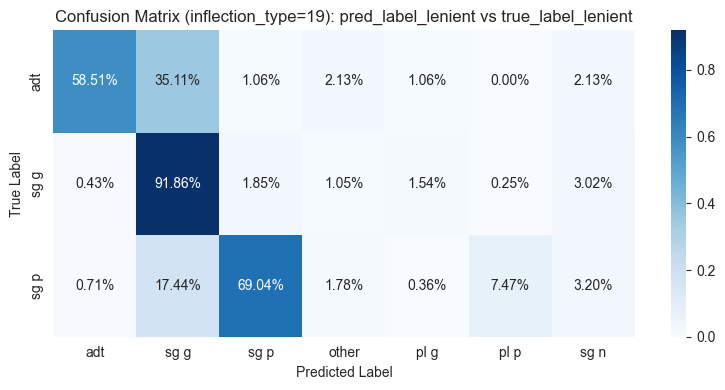

Confusion Matrix (inflection_type=19): pred_label_lenient vs true_label_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                 sg n     60       3.01              True              0
1                 pl g     27       1.35              True              0
2                 pl p     25       1.25              True              0
3                other     24       1.20              True              0
Sum of true labels count: 1996


In [18]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_label_lenient",
    true_col="true_label_lenient",
    group_col="inflection_type",
    fig_size=(8, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

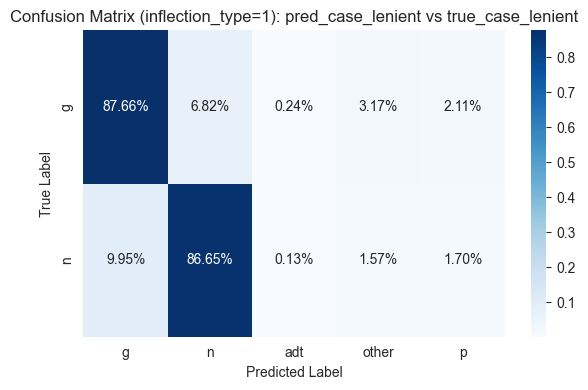

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     51       2.56              True              0
1                    p     39       1.95              True              0
2                  adt      4       0.20              True              0
Sum of true labels count: 1996


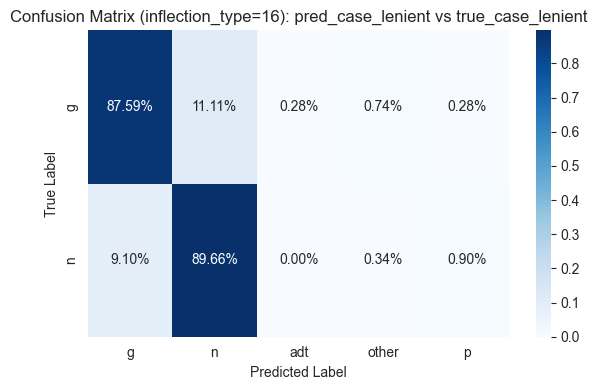

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     11       0.56              True              0
1                    p     11       0.56              True              0
2                  adt      3       0.15              True              0
Sum of true labels count: 1970


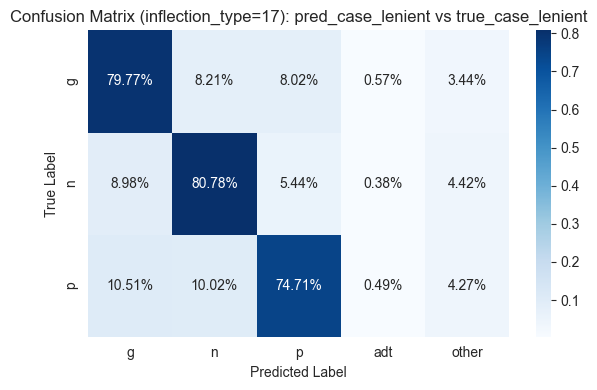

Confusion Matrix (inflection_type=17): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                other     79       4.11              True              0
1                  adt      9       0.47              True              0
Sum of true labels count: 1924


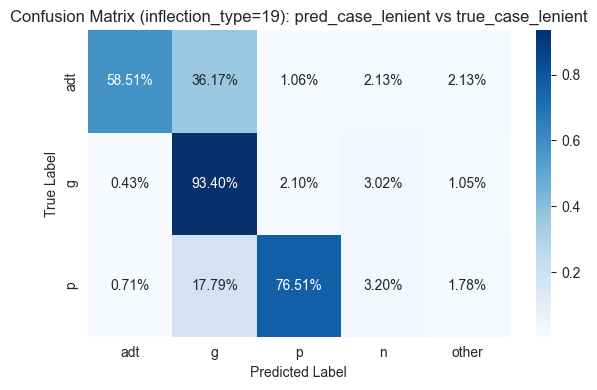

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n     60       3.01              True              0
1                other     24       1.20              True              0
Sum of true labels count: 1996


In [19]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR / model_name / f"{model_name}_CM_lenient_case_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

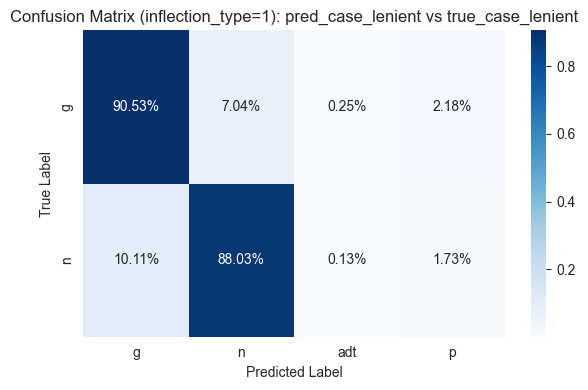

Confusion Matrix (inflection_type=1): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p     39       2.01              True              0
1                  adt      4       0.21              True              0
Sum of true labels count: 1945


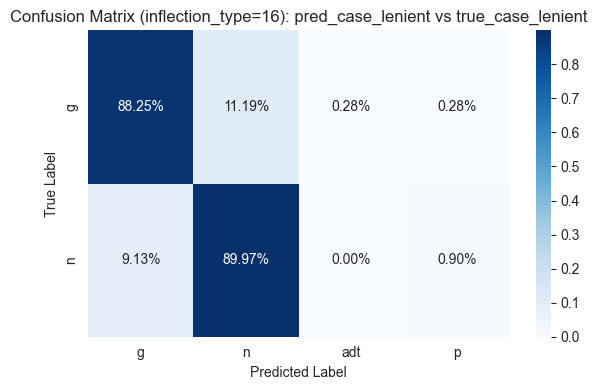

Confusion Matrix (inflection_type=16): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    p     11       0.56              True              0
1                  adt      3       0.15              True              0
Sum of true labels count: 1959


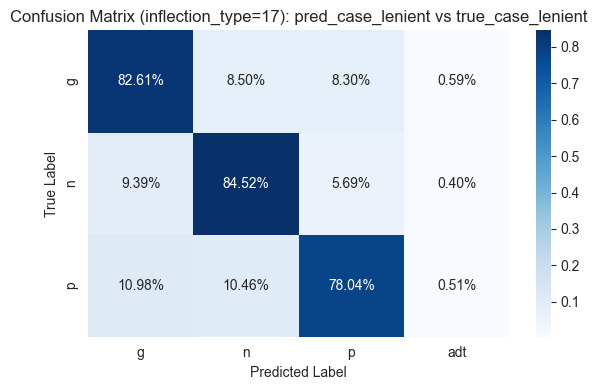

Confusion Matrix (inflection_type=17): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                  adt      9       0.49              True              0
Sum of true labels count: 1845


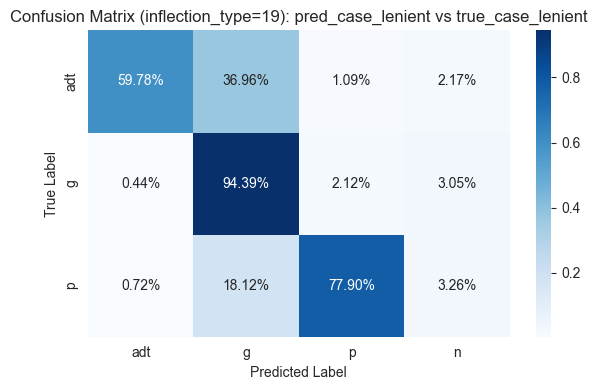

Confusion Matrix (inflection_type=19): pred_case_lenient vs true_case_lenient - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    n     60       3.04              True              0
Sum of true labels count: 1972


In [20]:
# Plot confusion matrices per inflection type
plot_confusion_matrices(
    results_df=results_df_filtered_possibles,
    pred_col="pred_case_lenient",
    true_col="true_case_lenient",
    group_col="inflection_type",
    fig_size=(6, 4),
    save_path=str(
        HOMONYMS_PLOTS_DIR
        / model_name
        / f"{model_name}_CM_lenient_case_possibles_infl.png"
    ),
    significant_pred_threshold_pct=0,
)

<a id='tulemuste_analyys'></a>


### Analyzing the results


In [ ]:
# Inspect LLM MLM predictions where the model got the prediction wrong
results_df["correct"] = results_df["pred_label"] == results_df["true_label"]

In [ ]:
display(results_df[~results_df["correct"]].head(20))

,id,candidates,pred_label,true_label,predicted_form_distribution,source_sentence,target_word,word_span,inflection_type,correct
0,0,"[saaja, pälvija, laureaadi, kandidaadi, osavõtja, pretendendi, võistleja, tiitliomaniku, võidumehe, austatu]",sg g,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': 0.8999999999999999, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.1, 'sg p': None, 'sg ter': None, 'sg tr': None, 'sid': None, 'tama': None, 'tavat': None, 'te': None, 'ti': None, 'tud': None, 'vad': None, 'vat': None}","Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",1,False
1,1,"[hüpoteesi, mudeli, käsitluse, lähenemise, kontseptsiooni, idee, doktriini, teooriate, kontseptsioonide, vaatenurga]",sg g,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': 0.2, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': 0.7, 'sg ill': None, 'sg in': None, 'sg kom': None, 'sg n': 0.1, 'sg p': None, 'sg ter': None, 'sg tr': None, 'sid': None, 'tama': None, 'tavat': None, 'te': None, 'ti': None, 'tud': None, 'vad': None, 'vat': None}","Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",1,False
13,13,"[Araabia Ühendemiraatidega, Poolaga, Rootsi, Tšiili, Brasiilia, Alžeeriaga, Itaaliaga, Mehhiko, Jaapaniga, Egiptusega]",sg kom,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, 'sg el': None, 'sg es': None, 'sg g': 0.30000000000000004, 'sg ill': None, 'sg in': None, 'sg kom': 0.5, 'sg n': 0.2, 'sg p': None, 'sg ter': None, 'sg tr': None, 'sid': None, 'tama': None, 'tavat': None, 'te': None, 'ti': None, 'tud': None, 'vad': None, 'vat': None}","Täna mängivad Omaan - Araabia Ühendemiraadid ja Iraan - Bahrein, homme kohtuvad Hiina - Usbekistan ja Tai Saudi Araabia.",Araabia,"[112, 119]",1,False
19,19,"[perioodi, aja, perioodi, kuu, periood, nädala, perioodi, päeva, aastat, kestuse]",sg p,sg n,"{'': None, '?': None, 'adt': None, 'b': None, 'd': None, 'da': None, 'des': None, 'ge': None, 'ks': None, 'ma': None, 'mas': None, 'mast': None, 'mata': None, 'me': None, 'n': None, 'neg o': None, 'nud': None, 'o': None, 'pl ab': None, 'pl abl': None, 'pl ad': None, 'pl all': None, 'pl el': None, 'pl es': None, 'pl g': None, 'pl ill': None, 'pl in': None, 'pl kom': None, 'pl n': None, 'pl p': None, 'pl ter': None, 'pl tr': None, 's': None, 'sg ab': None, 'sg abl': None, 'sg ad': None, 'sg all': None, '

In [ ]:
# Count how many mispredictions there are per inflection type
mispredictions_by_inflection = (
    results_df[~results_df["correct"]]
    .groupby("inflection_type")
    .size()
    .reset_index(name="count")
)
print("Mispredictions by inflection type:")
print(mispredictions_by_inflection)

Mispredictions by inflection type:
   inflection_type  count
0                1    271
1               16    231
2               17    522
3               19    262


In [ ]:
filtered_df = results_df[~results_df["correct"]]
filtered_df = filtered_df[
    (filtered_df["true_label"] == "sg n") & (filtered_df["pred_label"] == "sg g")
]

# Format printing of incorrect predictions for easier inspection
for i, (idx, row) in enumerate(filtered_df.iterrows()):
    sentence = row["source_sentence"]
    word = row["target_word"]
    candidates = row["candidates"]
    predicted_form_distribution = row["predicted_form_distribution"]
    inflection_type = row["inflection_type"]
    true_label = row["true_label"]
    pred_label = row["pred_label"]

    # Sort the predicted form distribution by probability in descending order
    # Most labels have None, so we need to handle that when sorting
    sorted_predicted_form_distribution = dict(
        sorted(
            predicted_form_distribution.items(),
            key=lambda item: item[1] if item[1] is not None else 0,
            reverse=True,
        )
    )
    print(f"Sentence: {sentence}")
    print(f"Word: {word}")
    print(f"Inflection type: {inflection_type}")
    print(f"True label: {true_label}, Predicted label: {pred_label}")
    print("Candidates: ")
    print("  -", end=" ")
    for c_i, candidate in enumerate(candidates):
        if c_i + 1 == len(candidates):
            print(f"{candidate}")
        else:
            print(f"{candidate},", end=" ")
    print("Predicted form distribution (sorted): ")
    for label, prob in sorted_predicted_form_distribution.items():
        if prob is not None:
            print(f"  - {label}: {prob}")
    print("-" * 50)
    if i >= 20:  # Limit to first 20 incorrect predictions for inspection
        break

Sentence: Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.
Word: võitja
Inflection type: 1
True label: sg n, Predicted label: sg g
Candidates: 
  - saaja, pälvija, laureaadi, kandidaadi, osavõtja, pretendendi, võistleja, tiitliomaniku, võidumehe, austatu
Predicted form distribution (sorted): 
  - sg g: 0.8999999999999999
  - sg n: 0.1
--------------------------------------------------
Sentence: Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.
Word: teooria
Inflection type: 1
True label: sg n, Predicted label: sg g
Candidates: 
  - hüpoteesi, mudeli, käsitluse, lähenemise, kontseptsiooni, idee, doktriini, teooriate, kontseptsioonide, vaatenurga
Predicted form distribution (sorted): 
  - sg g: 0.7
  - pl g: 0.2
  - sg n: 0.1
------------------